# ProteinBursty model demo

This notebook demonstrates the **ProteinBursty** model — a three-species extension
of the Bursty model that tracks unspliced RNA, spliced RNA, and protein jointly.

| Parameter | Symbol | Meaning |
|---|---|---|
| Burst size | *b* | Mean number of transcripts per burst |
| mRNA degradation | *β* | Degradation rate of unspliced mRNA |
| Splicing rate | *γ* | Splicing / mature mRNA degradation rate |
| Protein production | *k_p* | Translation rate |
| Protein degradation | *γ_p* | Protein degradation rate |

**Note:** Each PSS evaluation takes ~2 s on CPU (the ODE is integrated per grid point).
Fitting runs Nelder-Mead for ~100 evaluations ≈ 3–4 minutes total.


In [1]:
import sys, os
sys.path.insert(0, os.path.join('src', 'monod'))
os.chdir(os.path.join(os.path.dirname(os.path.abspath('')) if '__file__' in dir() else os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import anndata as ad
import time

from cme_toolbox import CMEModel
from extract_data import extract_data

# Check which backends are active
from cme_toolbox import _HAS_RUST, _HAS_GPU
os.makedirs('figures', exist_ok=True)
print(f'Rust backend: {_HAS_RUST}')
print(f'GPU  backend: {_HAS_GPU}')

Rust backend: True
GPU  backend: False


---
## 1 · Load data

The bundled `example_adata.h5ad` contains ~66 k cells with unspliced, spliced,
and **protein** layers for gene **PTPRC**.

Cells  : 65,988
Genes  : 1
Layers : ['ambiguous', 'mature', 'nascent', 'protein', 'spliced', 'unspliced']

PTPRC — mean counts:
  unspliced : 1.42  (max 71)
  spliced   : 0.62  (max 34)
  protein   : 0.20  (max 76)


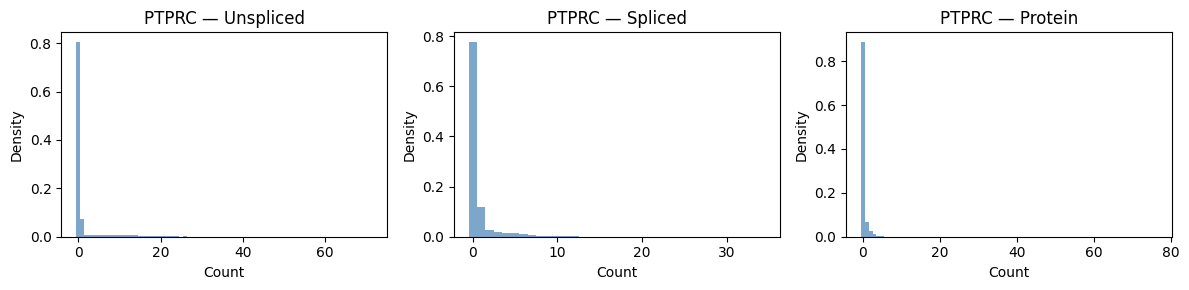

In [2]:
import scipy.sparse as sp

EXAMPLE_PATH = os.path.join('example_h5ad', 'example_adata.h5ad')
raw_adata = ad.read_h5ad(EXAMPLE_PATH)

print(f'Cells  : {raw_adata.n_obs:,}')
print(f'Genes  : {raw_adata.n_vars}')
print(f'Layers : {list(raw_adata.layers.keys())}')

def _dense(arr):
    return np.asarray(arr.todense()).ravel() if sp.issparse(arr) else np.asarray(arr).ravel()

gene = 'PTPRC'
u = _dense(raw_adata.layers['unspliced'][:, 0]).astype(int)
s = _dense(raw_adata.layers['spliced'][:, 0]).astype(int)
p = _dense(raw_adata.layers['protein'][:, 0]).astype(int)

print(f'\n{gene} — mean counts:')
print(f'  unspliced : {u.mean():.2f}  (max {u.max()})')
print(f'  spliced   : {s.mean():.2f}  (max {s.max()})')
print(f'  protein   : {p.mean():.2f}  (max {p.max()})')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, counts, label in zip(axes, [u, s, p], ['Unspliced', 'Spliced', 'Protein']):
    ax.hist(counts, bins=np.arange(counts.max() + 2) - 0.5, density=True, color='steelblue', alpha=0.7)
    ax.set_xlabel('Count'); ax.set_ylabel('Density')
    ax.set_title(f'{gene} — {label}')
plt.savefig('figures/protein_bursty_data.png', dpi=150, bbox_inches='tight')
plt.tight_layout(); plt.show()

---
## 2 · Preprocess with `extract_data`

`protein_limit=20` coarsens the protein axis of the PGF grid, reducing evaluation
time ~5× at the cost of slight approximation error.

PTPRC has low mean protein expression (< 1), so we pass `genes_to_fit` to bypass
the expression filter.

In [3]:
pb_model = CMEModel('ProteinBursty', 'None', protein_limit=20)

proc_adata = extract_data(
    raw_adata,
    pb_model,
    dataset_name='demo_protein_bursty',
    n_genes=1,
    viz=False,
    hist_type='unique',
    genes_to_fit=list(raw_adata.var_names),   # bypass expression filter
)

import sys
sys.path.insert(0, os.path.join('src', 'monod'))
from inference import searchdata_from_adata

M3 = proc_adata.uns['M'][:, 0].tolist()
search_data3 = searchdata_from_adata(proc_adata)
coords3, freqs3 = search_data3.hist[0]

print(f'Grid limits (unspliced, spliced, protein): {M3}')
print(f'Unique histogram points: {len(coords3)}')
print(f'Modalities: {list(proc_adata.uns["modality_name_dict"].keys())}')

The expected modalities for this model are: ['unspliced', 'spliced', 'protein']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
is sparse
0 genes retained after expression filter.


/Users/ConradOakes/monod/src/monod/extract_data.py:1039: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  gene_exp_filter[gene_loc[0]] = False  # Exclude from sampling pool


Grid limits (unspliced, spliced, protein): [81, 44, 86]
Unique histogram points: 1696
Modalities: ['unspliced', 'spliced', 'protein']


---
## 3 · Method-of-Moments initial estimate

`get_MoM` uses empirical moments to compute a fast closed-form starting point.
ProteinBursty has 5 parameters: *b*, *β*, *γ*, *k_p*, *γ_p*.

In [4]:
mom3 = {col: float(proc_adata.var[col].values[0])
        for col in proc_adata.var.columns if col.startswith('MOM_')}

lb3 = np.array(pb_model.bio_bounds['phys_lb'])
ub3 = np.array(pb_model.bio_bounds['phys_ub'])

p3_mom = pb_model.get_MoM(mom3, lb3, ub3, samp=np.zeros(2))

param_names_pb = ['log₁₀ b', 'log₁₀ β', 'log₁₀ γ', 'log₁₀ k_p', 'log₁₀ γ_p']
print('MoM parameter estimates (log₁₀ scale):')
for name, val in zip(param_names_pb, p3_mom):
    print(f'  {name} = {val:.3f}  →  {10**val:.4f}')

# Evaluate PSS and KLD at MoM
t0 = time.perf_counter()
pss3_mom = pb_model.eval_model_pss(p3_mom, M3)
print(f'\nPSS evaluation time: {time.perf_counter()-t0:.2f} s')
kld3_mom = pb_model.eval_model_kld(p3_mom, M3, None, (coords3, freqs3), 'unique')
print(f'KLD at MoM: {kld3_mom:.5f}')

MoM parameter estimates (log₁₀ scale):
  log₁₀ b = 1.110  →  12.8737
  log₁₀ β = 0.957  →  9.0654
  log₁₀ γ = 1.317  →  20.7365
  log₁₀ k_p = 1.359  →  22.8814
  log₁₀ γ_p = 1.847  →  70.3634

PSS evaluation time: 0.16 s


KLD at MoM: 2.10480


---
## 4 · Visualise the 3D distribution — pairwise projections

Since the PSS lives in a 3D grid (unspliced × spliced × protein), we plot
the three pairwise 2D marginals, with observed data overlaid as a scatter.

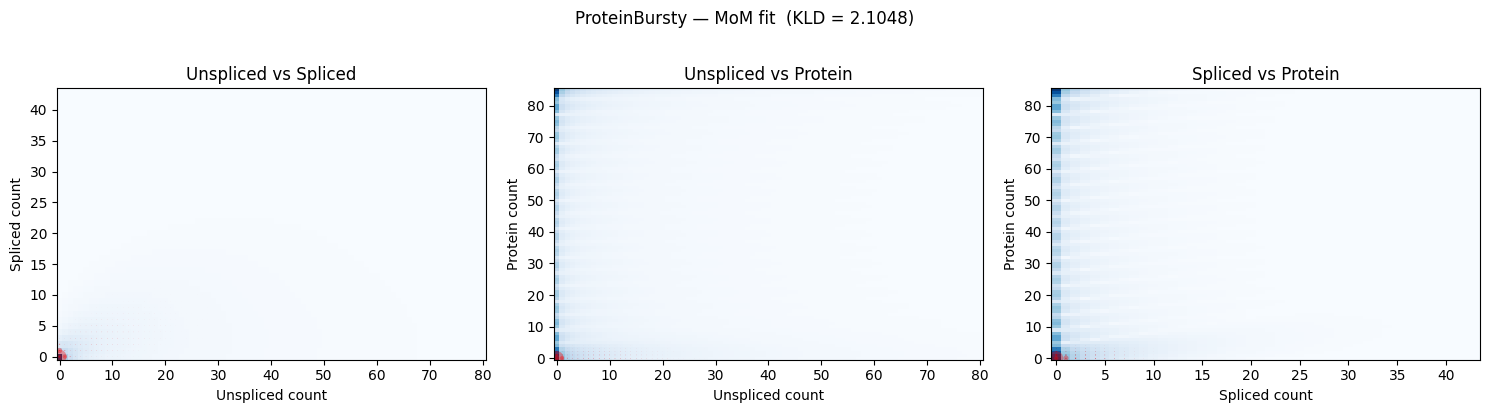

In [5]:
def plot_3d_projections(pss3, coords3, freqs3, M3, title):
    """Three pairwise marginal projections of a 3D PSS."""
    labels = ['Unspliced', 'Spliced', 'Protein']
    pairs  = [(0, 1), (0, 2), (1, 2)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (i, j) in zip(axes, pairs):
        # Sum over the third axis
        third = [k for k in range(3) if k not in (i, j)][0]
        pss2 = pss3.sum(axis=third)
        if i > j:                      # ensure (row=j, col=i) orientation
            pss2 = pss2.T
        ax.imshow(pss2.T, origin='lower', aspect='auto', cmap='Blues',
                  norm=mcolors.PowerNorm(gamma=0.4, vmin=0),
                  extent=[-0.5, M3[i]-0.5, -0.5, M3[j]-0.5])
        ax.scatter(coords3[:, i], coords3[:, j],
                   s=freqs3 * 150, c='red', alpha=0.35, linewidths=0)
        ax.set_xlabel(f'{labels[i]} count'); ax.set_ylabel(f'{labels[j]} count')
        ax.set_title(f'{labels[i]} vs {labels[j]}')
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.savefig('figures/protein_bursty_pss3d.png', dpi=150, bbox_inches='tight')
    plt.tight_layout(); plt.show()

plot_3d_projections(pss3_mom, coords3, freqs3, M3,
                    f'ProteinBursty — MoM fit  (KLD = {kld3_mom:.4f})')

---
## 5 · Gradient-descent optimisation

We minimise the KLD using Nelder-Mead — no gradient required, which avoids
`n_params` extra function evaluations per step that L-BFGS-B would need.

Each evaluation takes ~2 s; `maxiter=100` ≈ 3–4 minutes total.
Increase `maxiter` for tighter convergence in production.

In [6]:
from scipy.optimize import minimize

n3_evals = [0]

def objective3(p_log):
    n3_evals[0] += 1
    return pb_model.eval_model_kld(p_log, M3, None, (coords3, freqs3), 'unique')

t_opt = time.perf_counter()
result3 = minimize(
    objective3,
    x0=p3_mom,
    method='Nelder-Mead',
    options={'maxiter': 100, 'xatol': 1e-3, 'fatol': 1e-4},
)
t_opt = time.perf_counter() - t_opt

p3_opt   = result3.x
kld3_opt = result3.fun

print(f'Optimisation {"succeeded" if result3.success else "stopped"} '
      f'after {n3_evals[0]} evaluations  ({t_opt:.1f} s total)')
print(f'\nParameter comparison (log₁₀ scale):')
for name, vm, vo in zip(param_names_pb, p3_mom, p3_opt):
    print(f'  {name:12s}: MoM = {vm:.3f}  →  opt = {vo:.3f}  (Δ = {vo-vm:+.3f})')
print(f'\nKLD  MoM → opt:  {kld3_mom:.5f}  →  {kld3_opt:.5f}'
      f'  (improvement {kld3_mom-kld3_opt:.5f})')

Optimisation stopped after 164 evaluations  (36.0 s total)

Parameter comparison (log₁₀ scale):
  log₁₀ b     : MoM = 1.110  →  opt = 1.239  (Δ = +0.129)
  log₁₀ β     : MoM = 0.957  →  opt = 0.927  (Δ = -0.030)
  log₁₀ γ     : MoM = 1.317  →  opt = 1.259  (Δ = -0.058)
  log₁₀ k_p   : MoM = 1.359  →  opt = 0.473  (Δ = -0.887)
  log₁₀ γ_p   : MoM = 1.847  →  opt = 0.934  (Δ = -0.913)

KLD  MoM → opt:  2.10480  →  2.09751  (improvement 0.00728)


---
## 6 · Visualise the optimised fit

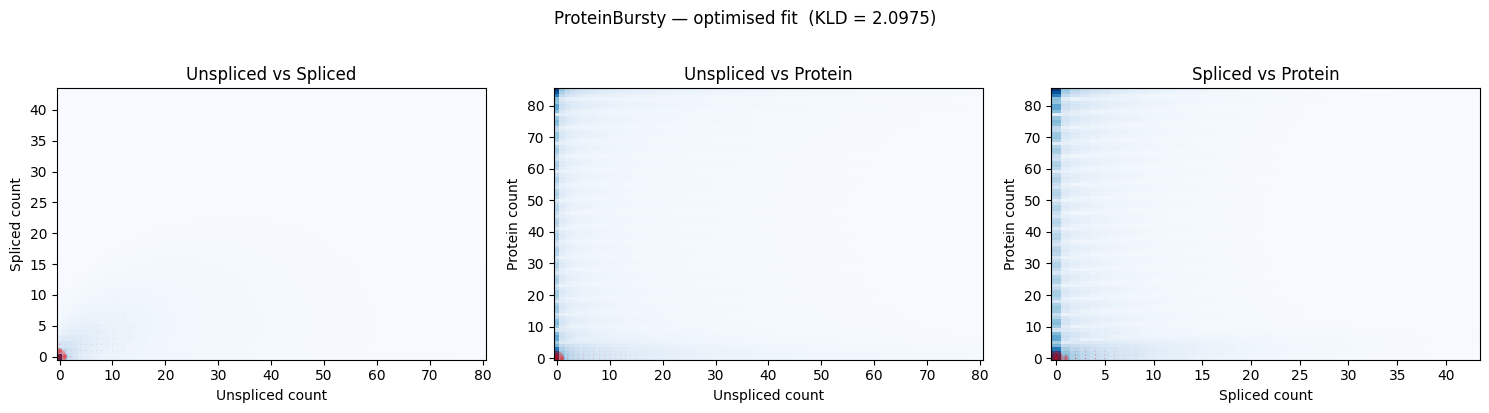

In [7]:
pss3_opt = pb_model.eval_model_pss(p3_opt, M3)
plot_3d_projections(pss3_opt, coords3, freqs3, M3,
                    f'ProteinBursty — optimised fit  (KLD = {kld3_opt:.4f})')

---
## 7 · MoM vs optimised — marginal comparison

Plot all three marginals side-by-side to see where the optimiser improved the fit.

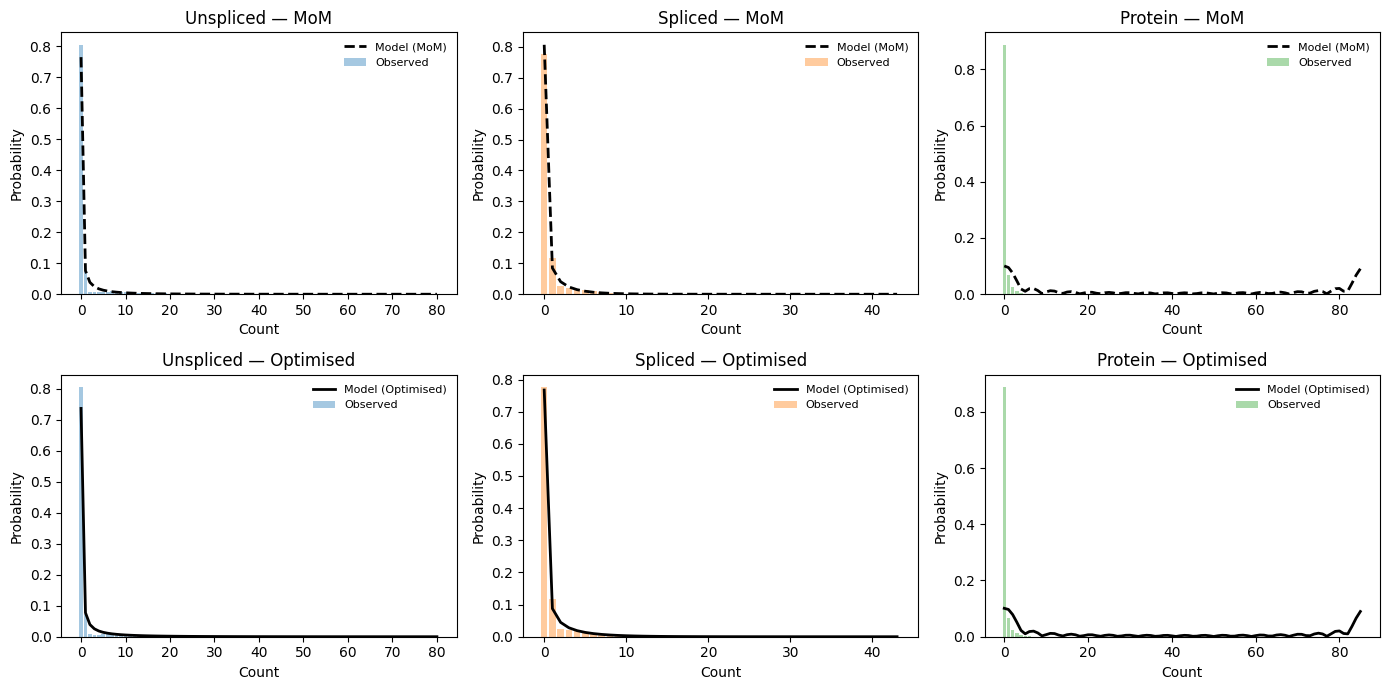

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
modality_labels = ['Unspliced', 'Spliced', 'Protein']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Empirical marginals from the unique histogram
obs_marg = [np.zeros(M3[d]) for d in range(3)]
for pt, f in zip(coords3, freqs3):
    for d in range(3):
        if int(pt[d]) < M3[d]:
            obs_marg[d][int(pt[d])] += f

for col, (label, color) in enumerate(zip(modality_labels, colors)):
    obs = obs_marg[col]
    # sum over the other two axes
    pss_m_mom = pss3_mom.sum(axis=tuple(d for d in range(3) if d != col))
    pss_m_opt = pss3_opt.sum(axis=tuple(d for d in range(3) if d != col))

    for row, (ax, pss_m, fit_label, ls) in enumerate(zip(
            axes[:, col],
            [pss_m_mom, pss_m_opt],
            ['MoM', 'Optimised'],
            ['--', '-'])):
        ax.bar(np.arange(len(obs)), obs, color=color, alpha=0.4, label='Observed')
        ax.plot(np.arange(len(pss_m)), pss_m, 'k', lw=2,
                linestyle=ls, label=f'Model ({fit_label})')
        ax.set_xlabel('Count'); ax.set_ylabel('Probability')
        ax.set_title(f'{label} — {fit_label}')
        ax.legend(frameon=False, fontsize=8)

plt.savefig('figures/protein_bursty_fit.png', dpi=150, bbox_inches='tight')
plt.tight_layout(); plt.show()

---
## 8 · Fitted parameter interpretation

In [9]:
print('Fitted ProteinBursty parameters for PTPRC:')
print()
for name, val_log in zip(param_names_pb, p3_opt):
    val = 10**val_log
    print(f'  {name} = {val_log:.3f}  →  {val:.4f}')

b, beta, gamma, k_p, gamma_p = 10**p3_opt
print(f'\nDerived quantities:')
print(f'  Mean burst size          b       = {b:.2f}')
print(f'  mRNA half-life     ln2/β  = {np.log(2)/beta:.2f} a.u.')
print(f'  Splicing half-life  ln2/γ  = {np.log(2)/gamma:.2f} a.u.')
print(f'  Protein production rate k_p     = {k_p:.2f}')
print(f'  Protein half-life  ln2/γ_p= {np.log(2)/gamma_p:.2f} a.u.')
print(f'  Mean mRNA   ≈ b·β/(β·γ)       = {b*beta/(beta*gamma):.2f}')
print(f'  Mean protein ≈ k_p/γ_p        = {k_p/gamma_p:.2f}')

Fitted ProteinBursty parameters for PTPRC:

  log₁₀ b = 1.239  →  17.3203
  log₁₀ β = 0.927  →  8.4588
  log₁₀ γ = 1.259  →  18.1544
  log₁₀ k_p = 0.473  →  2.9696
  log₁₀ γ_p = 0.934  →  8.5936

Derived quantities:
  Mean burst size          b       = 17.32
  mRNA half-life     ln2/β  = 0.08 a.u.
  Splicing half-life  ln2/γ  = 0.04 a.u.
  Protein production rate k_p     = 2.97
  Protein half-life  ln2/γ_p= 0.08 a.u.
  Mean mRNA   ≈ b·β/(β·γ)       = 0.95
  Mean protein ≈ k_p/γ_p        = 0.35
